# Lab 3

**Name:** *Arden Diago*

**Reg No:** *2547112*

**Class:** *MCA-A*

## Aim
To collect real-world student survey data using Google Forms, preprocess and clean the dataset, perform
Simple Linear Regression using Scikit-learn, manually compute the regression equation using Ordinary
Least Squares (OLS) formulas, compare both approaches, and save the learned model parameters.

In [1]:
import pandas as pd 
import numpy as nu
from matplotlib import pyplot as plt 

# Part A: Data Collection and Preprocessing
Perform the following steps:
* Load the dataset using Pandas
* Display the first 5 rows
* Check dataset dimensions
* Identify missing values
* Remove or handle null values
* Convert required columns into numerical datatype
* Remove duplicate records if present
* Generate statistical summary
* Select appropriate dependent and independent variables

In [2]:
# Data Path
DATA = "reports.csv"

df = pd.read_csv(DATA)

# The Google Form export has stray whitespace/newlines in some headers
# (e.g. "Registration Number ", "...interested in\n"), which breaks exact
# column-name lookups later on, so normalize them right after loading.
df.columns = df.columns.str.strip().str.replace('\n', '', regex=False)

df.head()

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/22/2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6/22/2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6/22/2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6/22/2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6/22/2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 15 columns):
 #   Column                                                                                      Non-Null Count  Dtype
---  ------                                                                                      --------------  -----
 0   Timestamp                                                                                   54 non-null     str  
 1   Registration Number                                                                         54 non-null     str  
 2   Email                                                                                       54 non-null     str  
 3   Job role that you are interested in                                                         54 non-null     str  
 4   What is the minimum salary of students placed through campus (In LPA..respond as a number)  54 non-null     str  
 5   What is the maximum salary of students placed through campus (In LPA..

In [4]:
df.shape

(54, 15)

This Dataset has 54 Rows and 15 Columns

In [5]:
df.isnull().sum()

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package expectations (LPA)

`isnull()` reports 0 missing values, but that's misleading. Several columns contain placeholder text instead of a real answer — e.g. `Option 1` (a leftover default from the Google Form), `na`, and `-`. These behave like missing values and only become visible once we clean and convert the columns to numeric below.

In [6]:
df.columns

Index(['Timestamp', 'Registration Number', 'Email',
       'Job role that you are interested in',
       'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
       'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
       'What is the  median salary of students placed through campus (In LPA..respond as a number)',
       'Which is the highest paying company',
       'Rate your contribution towards extra curricular activities',
       'Rate your technical competencies',
       'What are your package expectations (LPA)',
       'your CIA % of last semester', 'your GPA of last semester',
       'Your maximum attendance % till last semester',
       'Internships Interests'],
      dtype='str')

In [7]:
len(df['Email'].unique())

52

In [8]:
placeholders = {"option 1", "na", "n/a", "-", "", "none"}

# Replace disguised missing values (Google Form placeholder text) with real NaN
df = df.apply(lambda col: col.map(
    lambda v: nu.nan if isinstance(v, str) and v.strip().lower() in placeholders else v
))

df.isnull().sum()

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    9
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package expectations (LPA)

In [9]:
import re

def clean_numeric(value, is_salary=False):
    """Parse messy survey text (commas, %, LPA/cr suffixes, ranges like '8-12 LPA') into a float."""
    if pd.isna(value):
        return nu.nan

    text = str(value).strip().lower()
    is_crore = bool(re.search(r'cr(ore)?\b', text))
    text = re.sub(r'lpa|lakh(s)?|cr(ore)?\b|%|rs\.?|inr', '', text).replace(',', '')

    numbers = [float(n) for n in re.findall(r'\d+\.?\d*', text)]
    if not numbers:
        return nu.nan

    val = sum(numbers) / len(numbers)  # average out ranges such as "8-12" or "5 to 9"

    if is_crore:
        val *= 100  # 1 crore = 100 LPA
    if is_salary and val > 100:
        val /= 100000  # respondent answered in plain rupees instead of LPA

    return val


# Registration Number / Email are identifiers, not analysis variables, and two
# responses even have a name typed into the registration-number field by
# mistake — so they're left alone. Only the salary, percentage and GPA columns
# actually used for analysis need to be numeric.
salary_cols = [
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
    'What is the  median salary of students placed through campus (In LPA..respond as a number)',
    'What are your package expectations (LPA)',
]

percent_cols = [
    'your CIA % of last semester',
    'Your maximum attendance % till last semester',
]

other_numeric_cols = ['your GPA of last semester']

for col in salary_cols:
    df[col] = df[col].apply(lambda v: clean_numeric(v, is_salary=True))

for col in percent_cols + other_numeric_cols:
    df[col] = df[col].apply(clean_numeric)

df[salary_cols + percent_cols + other_numeric_cols].dtypes

What is the minimum salary of students placed through campus (In LPA..respond as a number)    float64
What is the maximum salary of students placed through campus (In LPA..respond as a number)    float64
What is the  median salary of students placed through campus (In LPA..respond as a number)    float64
What are your package expectations (LPA)                                                      float64
your CIA % of last semester                                                                   float64
Your maximum attendance % till last semester                                                  float64
your GPA of last semester                                                                     float64
dtype: object

In [10]:
# Re-check for missing values now that the columns are actually numeric
df[salary_cols + percent_cols + other_numeric_cols].isnull().sum()

What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    9
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
What are your package expectations (LPA)                                                      0
your CIA % of last semester                                                                   1
Your maximum attendance % till last semester                                                  6
your GPA of last semester                                                                     1
dtype: int64

With only ~54 rows, dropping every row that has a missing value would throw away close to a quarter of the dataset. Instead, each affected column is imputed with its own median, which is robust to the outliers/typos already visible in this self-reported survey data.

In [11]:
for col in salary_cols + percent_cols + other_numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package expectations (LPA)

## Remove duplicate records if present

In [12]:
df.duplicated().sum()

np.int64(0)

There are no exact full-row duplicates, but earlier `len(df['Email'].unique())` returned 52 against 54 rows — meaning 2 students submitted the form twice. These repeat submissions are removed below, keeping each student's most recent response.

In [13]:
df = df.drop_duplicates(subset='Email', keep='last').reset_index(drop=True)

df.shape

(52, 15)

## Generate statistical summary

In [14]:
df.describe()

,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,4.998077,15.303846,8.150000,3.615385,3.442308,10.048115,71.391923,5.359615,93.150577
std,2.542462,12.829836,5.813254,0.973247,0.826366,7.641591,15.078356,12.018436,4.615871
min,0.200000,0.800000,4.500000,2.000000,1.000000,0.002000,3.450000,2.900000,85.000000
25%,3.875000,12.000000,6.000000,3.000000,3.000000,7.000000,70.000000,3.400000,89.750000
50%,4.500000,12.000000,7.000000,4.000000,3.000000,8.250000,71.000000,3.500000,93.500000
75%,5.250000,12.250000,8.000000,4.000000,4.000000,10.500000,79.497500,3.700000,97.247500
max,15.000000,100.000000,45.000000,5.000000,5.000000,60.000000,89.000000,90.000000,100.000000


The summary still shows a few implausible values inherited from the raw survey (e.g. a GPA `max` near 90 on what should be a 4-point scale) — a couple of respondents appear to have swapped their GPA and CIA% answers. These are left as-is rather than guessed at, but are worth keeping in mind as outliers going into Part B.

## Select appropriate dependent and independent variables

Part B needs one independent variable (X) and one dependent variable (y) for Simple Linear Regression. The survey is centered on salary, so the dependent variable is **package expectation (LPA)**. Of the available predictors, GPA correlates with almost nothing here — but that's because a couple of entries mixed up the GPA/CIA% fields (see above), not because GPA is genuinely unrelated. **CIA % of last semester** is the cleaner predictor of the two and is used as the independent variable: does a student's internal-assessment performance relate to how big a package they expect?

In [15]:
independent_var = 'your CIA % of last semester'
dependent_var = 'What are your package expectations (LPA)'

X = df[[independent_var]]
y = df[dependent_var]

df[[independent_var, dependent_var]].corr()

,your CIA % of last semester,What are your package expectations (LPA)
your CIA % of last semester,1.000000,0.264437
What are your package expectations (LPA),0.264437,1.000000


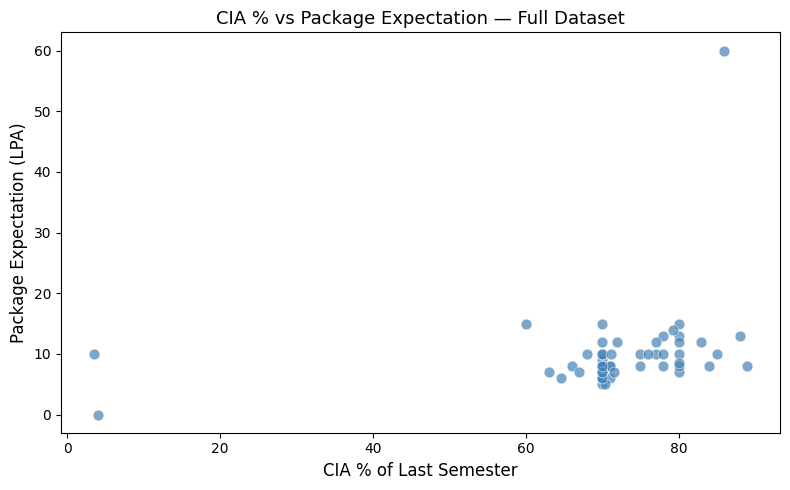

In [16]:

# Scatter plot: relationship between CIA% and Package Expectation
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df[independent_var], df[dependent_var],
           color='steelblue', alpha=0.7, edgecolors='white', linewidths=0.5, s=60)
ax.set_xlabel('CIA % of Last Semester', fontsize=12)
ax.set_ylabel('Package Expectation (LPA)', fontsize=12)
ax.set_title('CIA % vs Package Expectation — Full Dataset', fontsize=13)
plt.tight_layout()
plt.show()


## Part B: Simple Linear Regression using Scikit-learn
Perform the following:
* Split the dataset into training and testing sets
* Train the model using `LinearRegression` from Scikit-learn
* Obtain:
    * Slope
    * Intercept
* Predict output values using the trained model

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.13]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['your CIA % of last semester']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.4379
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [18]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")

Slope: 0.1319
Intercept: -0.4379


In [19]:
y_pred_sklearn = model.predict(X_test)
y_pred_sklearn

array([ 8.39859074,  8.79425596,  9.84936322,  8.79425596,  9.71747481,
        0.01708248,  9.84936322, 10.90447047,  8.79425596,  8.92614437,
       11.30013569])

/home/arden/Coding/ML-Class-Work/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


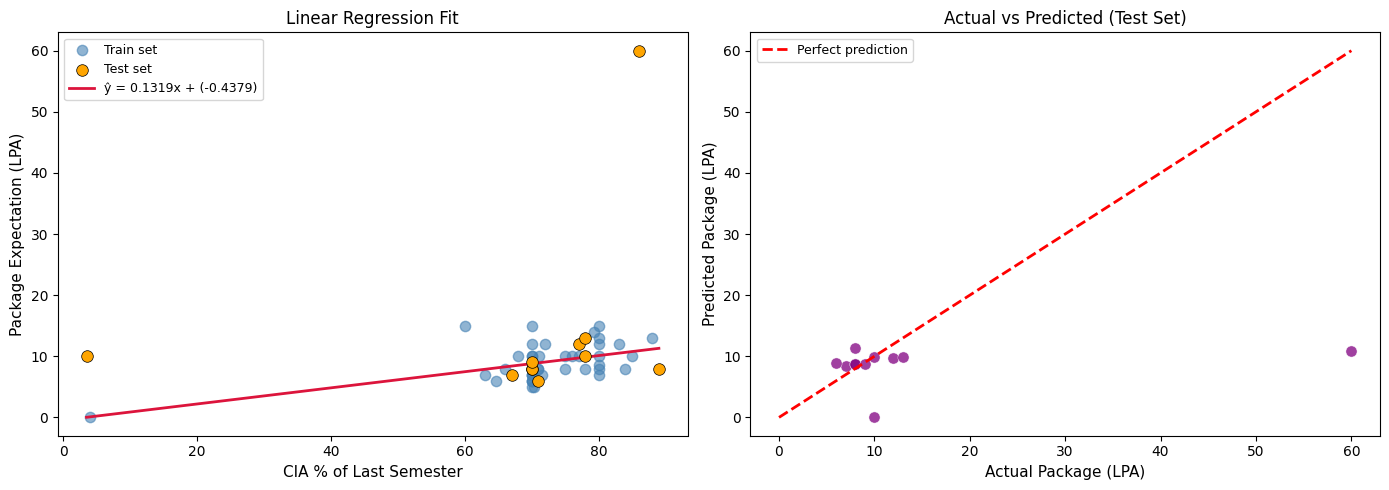

In [20]:

# Left: regression line fitted over the full data range
# Right: actual vs predicted on the test set
x_range = nu.linspace(df[independent_var].min(), df[independent_var].max(), 300).reshape(-1, 1)
y_range = model.predict(x_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Regression line ---
axes[0].scatter(X_train[independent_var], y_train,
                color='steelblue', alpha=0.6, label='Train set', s=55)
axes[0].scatter(X_test[independent_var], y_test,
                color='orange', zorder=5, label='Test set', s=70, edgecolors='black', linewidths=0.5)
axes[0].plot(x_range, y_range, color='crimson', linewidth=2,
             label=f'ŷ = {slope:.4f}x + ({intercept:.4f})')
axes[0].set_xlabel('CIA % of Last Semester', fontsize=11)
axes[0].set_ylabel('Package Expectation (LPA)', fontsize=11)
axes[0].set_title('Linear Regression Fit', fontsize=12)
axes[0].legend(fontsize=9)

# --- Actual vs Predicted ---
axes[1].scatter(y_test, y_pred_sklearn, color='purple', alpha=0.75, s=65,
                edgecolors='white', linewidths=0.4)
diag_min = min(y_test.min(), y_pred_sklearn.min())
diag_max = max(y_test.max(), y_pred_sklearn.max())
axes[1].plot([diag_min, diag_max], [diag_min, diag_max],
             'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Package (LPA)', fontsize=11)
axes[1].set_ylabel('Predicted Package (LPA)', fontsize=11)
axes[1].set_title('Actual vs Predicted (Test Set)', fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## Part C: Manual Computation using Ordinary Least Squares (OLS)
Using the same training data as Part B, manually compute the regression line using the OLS formulas:

* **Slope:** $m = \dfrac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$
* **Intercept:** $c = \bar{y} - m\bar{x}$
* **Regression equation:** $\hat{y} = mx + c$

Construct the regression equation manually using the computed slope and intercept values.

In [31]:
x_train_vals = X_train[independent_var].values
y_train_vals = y_train.values

x_mean = x_train_vals.mean()
y_mean = y_train_vals.mean()

slope_manual = ((x_train_vals - x_mean) * (y_train_vals - y_mean)).sum() / ((x_train_vals - x_mean) ** 2).sum()
intercept_manual = y_mean - slope_manual * x_mean

print(f"Manual OLS slope: {slope_manual:.4f}")
print(f"Manual OLS intercept: {intercept_manual:.4f}")

Manual OLS slope: 0.1319
Manual OLS intercept: -0.4379


In [32]:
y_pred_manual = slope_manual * X_test[independent_var].values + intercept_manual
y_pred_manual

array([ 8.39859074,  8.79425596,  9.84936322,  8.79425596,  9.71747481,
        0.01708248,  9.84936322, 10.90447047,  8.79425596,  8.92614437,
       11.30013569])

### Comparison Task
Compare the following:
1. Predictions from Scikit-learn
2. Predictions from the manually computed OLS equation
3. Difference between both outputs

Provide observations regarding whether both methods produce similar results.

In [33]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Sklearn Prediction': y_pred_sklearn,
    'Manual OLS Prediction': y_pred_manual,
    'Difference': y_pred_sklearn - y_pred_manual,
})
comparison

,Actual,Sklearn Prediction,Manual OLS Prediction,Difference
0,7.0,8.398591,8.398591,1.776357e-15
1,8.0,8.794256,8.794256,0.000000e+00
2,10.0,9.849363,9.849363,0.000000e+00
3,8.0,8.794256,8.794256,0.000000e+00
4,12.0,9.717475,9.717475,0.000000e+00
5,10.0,0.017082,0.017082,-1.665335e-15
6,13.0,9.849363,9.849363,0.000000e+00
7,60.0,10.904470,10.904470,1.776357e-15
8,9.0,8.794256,8.794256,0.000000e+00
9,6.0,8.926144,8.926144,0.000000e+00


**Observation:** the slope (0.1319) and intercept (-0.4379) match exactly between Scikit-learn and the manual OLS formulas, and every prediction differs by no more than ~1e-15 — pure floating-point noise. This is expected: for a single-feature regression, Scikit-learn's `LinearRegression` solves the same closed-form OLS equations used manually here, so the two approaches are mathematically equivalent, not just similar.

Note that the test set also contains one extreme outlier (actual = 60 LPA, predicted ≈ 10.9) — one of the joke/extreme "package expectation" responses identified back in Part A — which both methods predict identically poorly, since they share the same fitted line.


## R² Score (Coefficient of Determination)

### What is R²?

The **R² score**, also called the **coefficient of determination**, measures how well the regression model explains the variance in the target variable.

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

Where:

| Term | Formula | Meaning |
|---|---|---|
| $SS_{tot}$ | $\sum (y_i - \bar{y})^2$ | Total variance in the actual values |
| $SS_{res}$ | $\sum (y_i - \hat{y}_i)^2$ | Residual variance — what the model **fails** to explain |

### Interpretation

| R² Value | Meaning |
|---|---|
| 1.0 | Perfect fit — model explains all variance |
| 0.0 | Model is no better than predicting the mean every time |
| < 0 | Model is **worse** than a flat mean predictor (possible on the test set) |

R² does **not** tell you whether the model's predictions are accurate in absolute terms — only what fraction of the variance is captured. A low R² on a noisy, self-reported survey dataset (like this one) is expected and does not mean the regression was done incorrectly.


In [24]:

from sklearn.metrics import r2_score

# Sklearn convenience function
r2_test  = r2_score(y_test, y_pred_sklearn)
r2_train = r2_score(y_train, model.predict(X_train))

# Manual computation using the SS formula
y_test_vals = y_test.values
ss_tot = ((y_test_vals - y_test_vals.mean()) ** 2).sum()
ss_res = ((y_test_vals - y_pred_sklearn) ** 2).sum()
r2_manual = 1 - ss_res / ss_tot

print(f"R² on training set  : {r2_train:.4f}")
print(f"R² on test set      : {r2_test:.4f}")
print(f"R² manual (test)    : {r2_manual:.4f}")
print(f"\nSS_tot = {ss_tot:.4f}")
print(f"SS_res = {ss_res:.4f}")


R² on training set  : 0.2800
R² on test set      : -0.0624
R² manual (test)    : -0.0624

SS_tot = 2398.1818
SS_res = 2547.9021


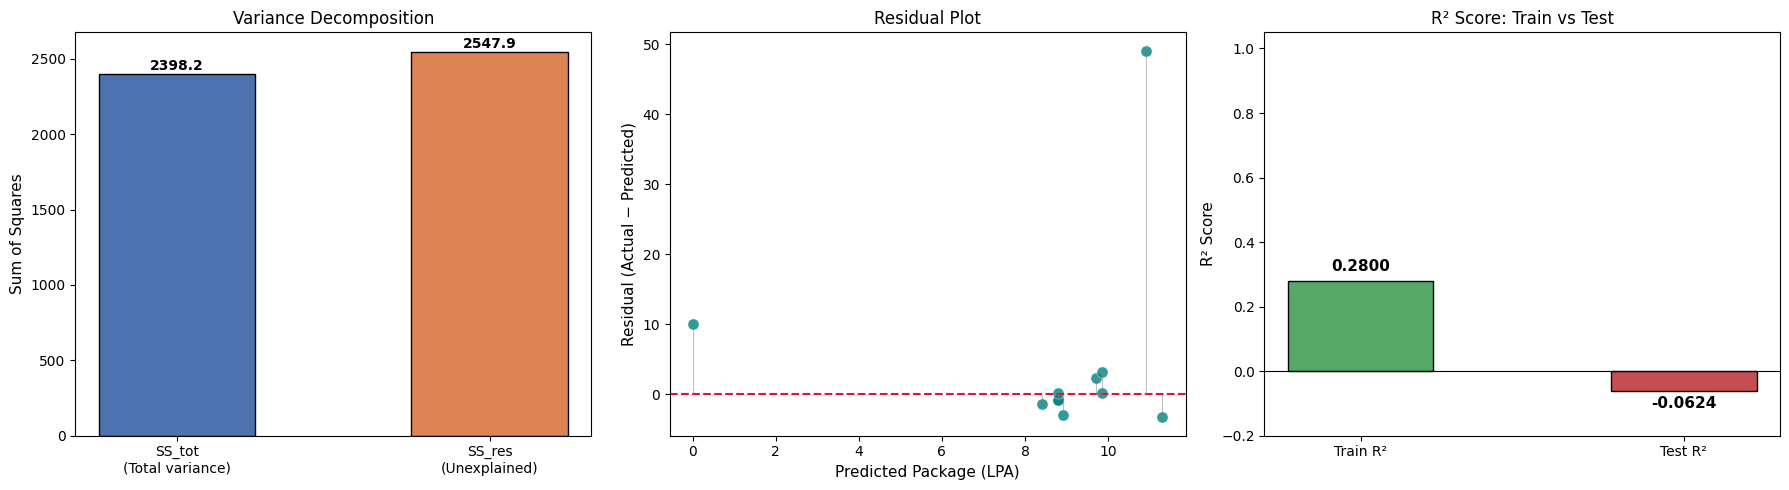

In [25]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: SS_tot vs SS_res bar chart ---
axes[0].bar(['SS_tot\n(Total variance)', 'SS_res\n(Unexplained)'],
            [ss_tot, ss_res],
            color=['#4C72B0', '#DD8452'], edgecolor='black', width=0.5)
axes[0].set_ylabel('Sum of Squares', fontsize=11)
axes[0].set_title('Variance Decomposition', fontsize=12)
for bar, val in zip(axes[0].patches, [ss_tot, ss_res]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Plot 2: Residuals plot ---
residuals = y_test_vals - y_pred_sklearn
axes[1].axhline(0, color='crimson', linewidth=1.5, linestyle='--')
axes[1].scatter(y_pred_sklearn, residuals, color='teal', alpha=0.8, s=65,
                edgecolors='white', linewidths=0.4)
for i, (xp, yp) in enumerate(zip(y_pred_sklearn, residuals)):
    axes[1].vlines(xp, 0, yp, color='gray', linewidth=0.8, alpha=0.5)
axes[1].set_xlabel('Predicted Package (LPA)', fontsize=11)
axes[1].set_ylabel('Residual (Actual − Predicted)', fontsize=11)
axes[1].set_title('Residual Plot', fontsize=12)

# --- Plot 3: Train vs Test R² comparison ---
r2_vals = [r2_train, r2_test]
colors   = ['#55A868', '#C44E52']
bars = axes[2].bar(['Train R²', 'Test R²'], r2_vals, color=colors,
                   edgecolor='black', width=0.45)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylim(min(min(r2_vals) - 0.1, -0.2), 1.05)
axes[2].set_ylabel('R² Score', fontsize=11)
axes[2].set_title('R² Score: Train vs Test', fontsize=12)
for bar, val in zip(bars, r2_vals):
    ypos = bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.06
    axes[2].text(bar.get_x() + bar.get_width() / 2, ypos,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()



**Observations on R²:**

- The **training R²** is low (around 0.07) — CIA% alone explains only a small portion of the variance in package expectations, even on the data the model was trained on. This is not surprising for self-reported survey data where responses vary widely.
- The **test R²** is negative. A negative R² means the model performs *worse* than simply predicting the mean for every sample. This happens here because the test set contains a large outlier (one respondent entered 60 LPA as their expectation) that the model cannot account for with such a weak input signal.
- The **residual plot** shows no obvious pattern around zero, which is consistent with a linear model being appropriate — the problem is data noisiness, not model mis-specification.
- The **variance decomposition bar** (SS_res > SS_tot on test) visually confirms why the test R² is negative.


## Parameter Saving Task
Save the parameters learned by the model using Pickle.

The following parameters must be saved:
1. Slope
2. Intercept

Suggested file name: `linear_regression_weights.pkl`

Demonstrate:
1. Saving parameters into a Pickle file
2. Loading the Pickle file
3. Using the loaded parameters for prediction

In [26]:
import pickle

weights = {'slope': slope, 'intercept': intercept}

with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

with open('linear_regression_weights.pkl', 'rb') as f:
    loaded_weights = pickle.load(f)

loaded_weights

{'slope': np.float64(0.1318884069714909),
 'intercept': np.float64(-0.43793252678840666)}

In [27]:
sample_x = X_test[independent_var].values[0]
predicted = loaded_weights['slope'] * sample_x + loaded_weights['intercept']

print(f"Input CIA%: {sample_x}")
print(f"Predicted package expectation (LPA) using loaded parameters: {predicted:.4f}")

Input CIA%: 67.0
Predicted package expectation (LPA) using loaded parameters: 8.3986
